# Global Graduate Opportunities Tracker

## Project Objective

This project analyzes graduate opportunities across different countries using Python, SQL, MySQL, and data visualization techniques. The goal is to identify hiring trends, in-demand technical skills, and international graduate opportunities.

## Data Loading and Exploration

The dataset is loaded into a Pandas DataFrame and explored to understand its structure, columns, and summary statistics.

In [ ]:
import pandas as pd

df = pd.readcsv(r"C:\Users\nihar\OneDrive\Desktop\Global-Graduate-Opportunities-Tracker\data\graduate_jobs.csv")


In [ ]:
df.head()

In [ ]:

df.columns


In [ ]:
df.info()


In [ ]:
df.describe()


In [ ]:
df["country"].value_counts()

## Country Analysis

This analysis identifies which countries have the highest number of graduate opportunities in the dataset.

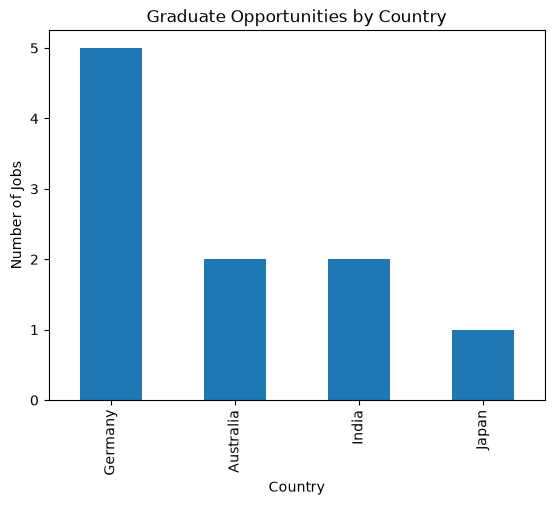

['Python', 'SQL', 'Power BI', 'Java', 'SQL', 'Git', 'Python', 'AWS', 'Data Structures', 'Python', 'Power BI', 'SQL', 'Java', 'SQL', 'Spring Boot', 'Python', 'SQL', 'Azure', 'Java', 'SQL', 'Linux', 'Java', 'Python', 'Git', 'Python', 'Power BI', 'Excel', 'Python', 'Django', 'JavaScript']
Counter({'Python': 7, 'SQL': 6, 'Java': 4, 'Power BI': 3, 'Git': 2, 'AWS': 1, 'Data Structures': 1, 'Spring Boot': 1, 'Azure': 1, 'Linux': 1, 'Excel': 1, 'Django': 1, 'JavaScript': 1})
Python: 7
SQL: 6
Java: 4
Power BI: 3
Git: 2
AWS: 1
Data Structures: 1
Spring Boot: 1
Azure: 1
Linux: 1
Excel: 1
Django: 1
JavaScript: 1


In [18]:
import matplotlib.pyplot as plt

df["country"].value_counts().plot(kind="bar")

plt.title("Graduate Opportunities by Country")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")

plt.show()

df["skills"]
df["skills"].tolist()
all_skills = []

for skill_group in df["skills"]:
    split_skills = skill_group.split(";")
    all_skills.extend(split_skills)

print(all_skills)

from collections import Counter

skill_counts = Counter(all_skills)

print(skill_counts)

skill_counts.most_common()

for skill, count in skill_counts.most_common():
    print(f"{skill}: {count}")

## Skills Analysis

Skills are extracted from job postings and analyzed to identify the most frequently requested technical competencies.

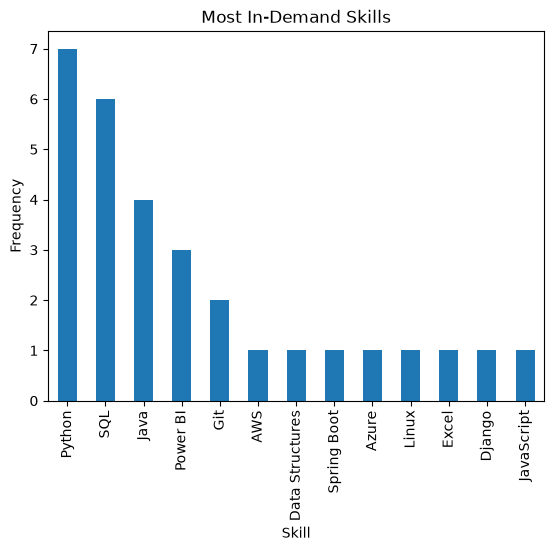

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

skills_df = pd.DataFrame(
    skill_counts.most_common(),
    columns=["Skill", "Count"]
)

skills_df

skills_df.plot(
    x="Skill",
    y="Count",
    kind="bar",
    legend=False
)

plt.title("Most In-Demand Skills")
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.show()

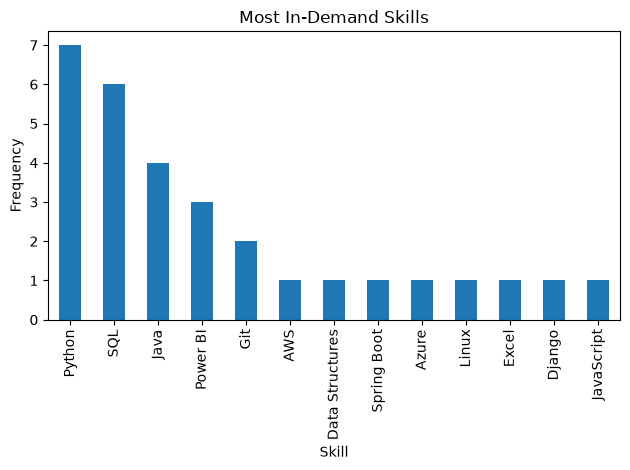

In [21]:
skills_df.plot(
    x="Skill",
    y="Count",
    kind="bar",
    legend=False
)

plt.title("Most In-Demand Skills")
plt.xlabel("Skill")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../screenshots/top_skills.png")

plt.show()

## MySQL Database Integration

The dataset is stored in a MySQL database and queried using SQL. Python retrieves query results for further analysis and visualization.

In [22]:
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Nihara04$",
    database="graduate_tracker"
)

print("Connected successfully!")

Connected successfully!


In [26]:
import pandas as pd

query = "SELECT * FROM graduate_jobs"

df_sql = pd.read_sql(query, connection)

df_sql.head()
print(df_sql.shape)
df_sql.columns
print(df_sql.head())

print("\nShape:")
print(df_sql.shape)

print("\nColumns:")
print(df_sql.columns)

(3, 8)
   id   company                            role    country   location  \
0   1  Deloitte  Graduate Technology Consultant  Australia     Sydney   
1   2       IBM       Associate System Engineer      India  Bangalore   
2   3    Amazon      Graduate Software Engineer    Germany     Berlin   

                       skills visa_sponsorship posted_date  
0         Python;SQL;Power BI              Yes  2026-06-23  
1                Java;SQL;Git               No  2026-06-23  
2  Python;AWS;Data Structures              Yes  2026-06-23  

Shape:
(3, 8)

Columns:
Index(['id', 'company', 'role', 'country', 'location', 'skills',
       'visa_sponsorship', 'posted_date'],
      dtype='str')


C:\Users\nihar\AppData\Local\Temp\ipykernel_9056\4130293242.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql(query, connection)


## SQL-Based Country Analysis

SQL is used to group opportunities by country and calculate the total number of opportunities available in each location.

In [27]:
query = """
SELECT
    country,
    COUNT(*) AS total_jobs
FROM graduate_jobs
GROUP BY country
ORDER BY total_jobs DESC
"""

country_df = pd.read_sql(query, connection)

country_df

C:\Users\nihar\AppData\Local\Temp\ipykernel_9056\1179509557.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  country_df = pd.read_sql(query, connection)


,country,total_jobs
0,Australia,1
1,India,1
2,Germany,1


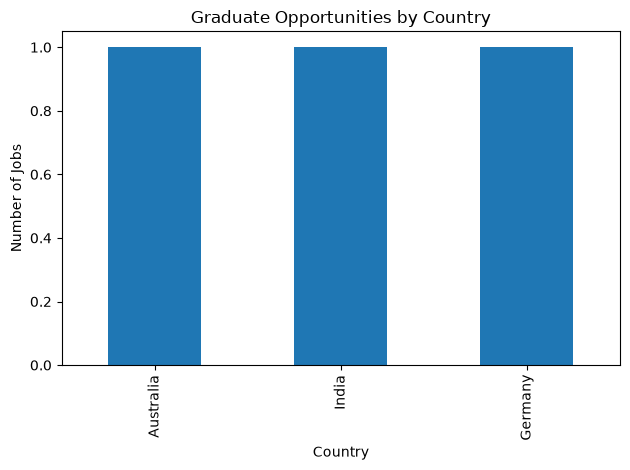

In [28]:
import matplotlib.pyplot as plt

country_df.plot(
    x="country",
    y="total_jobs",
    kind="bar",
    legend=False
)

plt.title("Graduate Opportunities by Country")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")

plt.tight_layout()

plt.show()

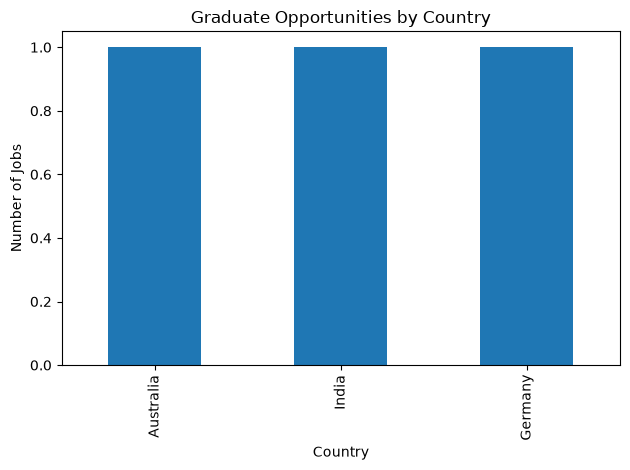

In [29]:
country_df.plot(
    x="country",
    y="total_jobs",
    kind="bar",
    legend=False
)

plt.title("Graduate Opportunities by Country")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")

plt.tight_layout()

plt.savefig("../screenshots/jobs_by_country_sql.png")

plt.show()

# Key Findings

## Country Analysis

- Germany had the highest number of graduate opportunities in the sample dataset with 5 job postings.
- Australia and India each had 2 job postings.
- Japan had 1 job posting.

## Skills Analysis

- Python was the most frequently requested skill, appearing 7 times.
- SQL was the second most requested skill, appearing 6 times.
- Java appeared 4 times across software engineering and developer roles.
- Power BI and Git were also recurring skills in graduate opportunities.

## Initial Conclusions

- Python and SQL are the most in-demand skills in the analyzed graduate opportunities.
- Germany appears to offer a significant number of graduate opportunities compared to other countries in the sample dataset.
- Technical skills such as Python, SQL, Java, Git, and Power BI are commonly requested by employers.
- Candidates targeting international graduate programs should focus on strengthening programming, database, version control, and data analysis skills.

## Future Improvements

- Collect real graduate job opportunities from company career portals.
- Expand the dataset to include 100+ job postings.
- Analyze visa sponsorship trends by country and company.
- Build interactive dashboards using Power BI.
- Track hiring trends and emerging skill requirements over time.